In [ ]:
import numpy as np

import warnings
warnings.filterwarnings('ignore', category=UserWarning, append = True)

from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg, tebd
from tenpy.networks.mpo import MPO

from fisher_lg.State import State_Evo

import matplotlib.pyplot as plt
import matplotlib.ticker as tck

The bellow is a class constructed for the TFIM which is featured on the TeNPy website

In [43]:
model_params = {
    'J': 1 , 'g': .1,  # critical
    'L': 10,
    'bc_MPS': 'finite',
    'model_type' : "Ising",
    'conserve' : None
}

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : 4,  #Only even N_times are used for K,
    'dt': 0.02,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 3  #only an option for calculating the maximum of the LG correlator
}

psi = State_Evo.from_dmrg(model_params = model_params, dmrg_params = extra_params)
print(psi.calculate_LG_bound(op = 'Sigmax',op_sum= True))


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=5.36e-05


(0.32, np.float64(0.0011982796398157802), None)


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=2.12e-04


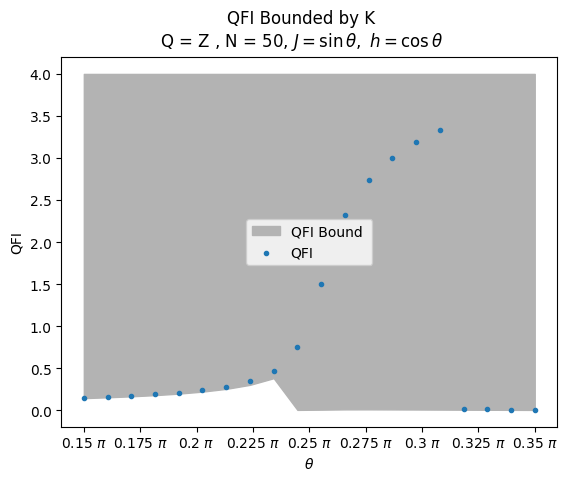

In [35]:
L = 50
chi_max = 40
op = 'Sigmax'
num_points = 20

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : 2,  #Only even N_times are used for K,
    'dt': 0.02,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 30,  #only an option for calculating the maximum of the LG correlator
    'return_QFI' : True  #an option for some functions which also returns the QFI
}

theta_range = np.linspace(0.15 * np.pi, 0.35 * np.pi, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI_lst =[]
for theta in theta_range:
    J, g = np.sin(theta), np.cos(theta)

    model_params = {
    'J':  J , 'g':  g, 
    'L': L,
    'model_type' : 'Ising',
    'bc_MPS': 'finite',
    'conserve' : None}
    psi = State_Evo.from_dmrg(model_params, extra_params)
    t_max, LG_max , qfi = psi.calculate_LG_bound(op, return_QFI= True)
    LG_bound += [LG_max]
    QFI_lst += [qfi]

ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, QFI_lst, marker = '.', label = "QFI", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = Z , N = " + str(L) + ", $J = \\sin\\theta,~h = \\cos\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

In [7]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_L50_Ztot_QFI_Bound.png")

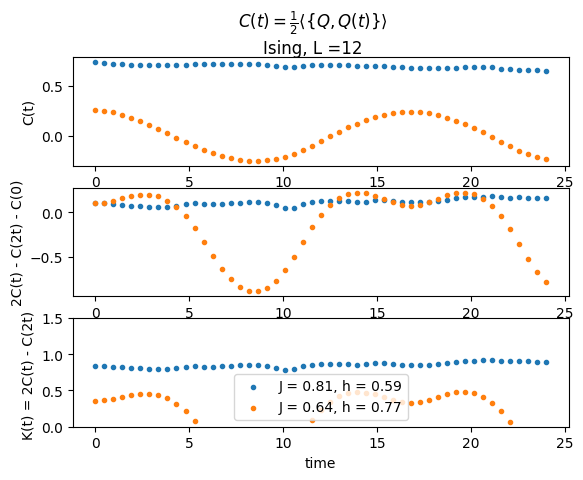

In [27]:
L = 12
chi_max = 40
op = 'Sigmax'
num_points = 50
t_end = 25
dt = 0.02
Jg_lst = [[np.sin(.3 * np.pi), np.cos(.3 * np.pi)],[np.sin(.22 * np.pi), np.cos(.22 * np.pi)]]

fig, ax = plt.subplots(3)

for J, g in Jg_lst: 

    model_params = {
        'J': J , 'g': g, 
        'L': L,
        'bc_MPS': 'finite',
        'model_type' : "Ising",
        'conserve' : None    }
    
    extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : num_points,
    'dt': dt,'N_steps': 2*int( t_end//(2*dt * num_points)),
    'order': 2, 'start_time' : 0,
    't_max' : 30}

    psi = State_Evo.from_dmrg(model_params, extra_params)

    """times, Ct = calculate_QtQ('Sigmax', model_params,  dmrg_tebd_params = extra_params)"""
    times, Ct = psi.calculate_QtQ('Sigmax', op_sum = True)
    ax[0].scatter(times, Ct, marker = '.', label = "J = " + str(J) + ", h = " + str(g), zorder = 3)
    times, LG_correl, Kt = psi.calculate_LG_correlator('Sigmax')
    ax[1].scatter(times, LG_correl, marker = '.', label = "J = " + str(round(J,2)) + ", h = " + str(round(g,2)), zorder = 3)
    ax[2].scatter(times, Kt, marker = '.', label = "J = " + str(round(J,2)) + ", h = " + str(round(g, 2)), zorder = 3)
    

fig.suptitle("$C(t) = \\frac{1}{2}\\langle \\{Q, Q(t) \\}\\rangle$\nIsing, L =" + str(L))
ax[2].xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
ax[1].set(ylabel = "2C(t) - C(2t) - C(0)")
ax[2].set(ylabel = "K(t) = 2C(t) - C(2t) ")
ax[2].set_ylim([0,1.5])
plt.legend()

plt.show()

In [22]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_L50_C_LG_K.png")

final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=5.78e-05
final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.47e-04


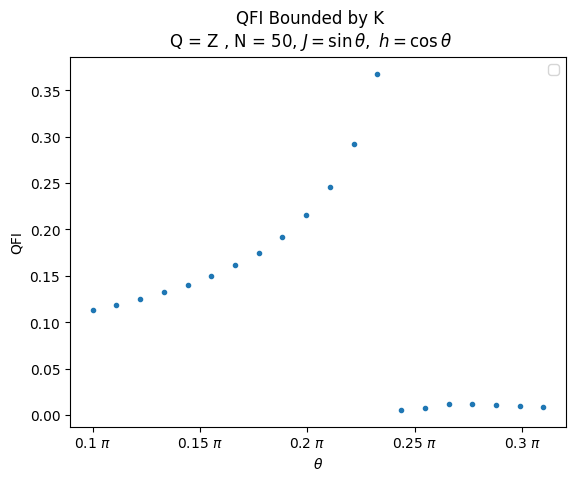

In [ ]:
L = 50
chi_max = 40
op = 'Sigmax'
num_points = 20

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': 30,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : 4,  #Only even N_times are used for K,
    'dt': 0.02,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 30  #only an option for calculating the bound
}

theta_range = np.linspace(0.10 * np.pi, 0.31 * np.pi, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI_lst =[]
for theta in theta_range:
    J, g = np.sin(theta), np.cos(theta)

    model_params = {
    'J':  J , 'g':  g,  # critical
    'L': L,
    'bc_MPS': 'finite',
    'conserve' : None}

    t_max, LG_max = calculate_LG_bound(op, model_params, extra_params )
    LG_bound += [LG_max]

#ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, LG_bound, marker = '.', label = "", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = Z , N = " + str(L) + ", $J = \\sin\\theta,~h = \\cos\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()